# Insurance Risk Analytics: Exploratory Data Analysis

## Executive Summary & Business Context

This notebook performs a comprehensive EDA on the ACIS insurance dataset
covering February 2014 to August 2015.

**Analytical Objectives:**
- Understand the structure and quality of the data
- Uncover patterns in risk and profitability
- Answer key business questions around loss ratio, geographic trends, and vehicle risk

**Key Metrics:**
- **Loss Ratio** = TotalClaims / TotalPremium
- **Margin** = TotalPremium − TotalClaims
- **Claim Rate** = % of policies with at least one claim

## 1. Setup & Imports

In [39]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_data, get_basic_info
from src.eda_utils import (
    PALETTE,
    portfolio_summary,
    summarize_data,
    check_dtypes,
    missing_value_report,
    plot_numerical_distributions,
    plot_categorical_distributions,
    plot_correlation_matrix,
    plot_premium_vs_claims,
    plot_premium_vs_claims_by_postalcode,
    plot_claim_rate_by_group,
    plot_province_analysis,
    plot_boxplots,
    compute_loss_ratio,
    plot_vehicle_makes_by_claims
)

## 2. Load Data

In [40]:
df = load_data("../data/raw/MachineLearningRating_v3.txt")
get_basic_info(df)

Data loaded successfully: 1000098 rows, 52 columns

--- Shape ---
(1000098, 52)

--- Data Types ---
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth             object
IsVATRegistered                bool
Citizenship                  object
LegalType                    object
Title                        object
Language                     object
Bank                         object
AccountType                  object
MaritalStatus                object
Gender                       object
Country                      object
Province                     object
PostalCode                    int64
MainCrestaZone               object
SubCrestaZone                object
ItemType                     object
mmcode                      float64
VehicleType                  object
RegistrationYear              int64
make                         object
Model                        object
Cylinders                   float64
cubiccapacity               float64


## 3. Portfolio Summary

High-level metrics giving an immediate snapshot of the portfolio's health.

In [41]:
portfolio_summary(df)

,Metric,Value
0,Total Premiums Collected,"61,911,562.70"
1,Total Claims Paid,"64,867,546.17"
2,Overall Loss Ratio,1.0477
3,Claim Frequency (Rate %),0.28%
4,Average Cost per Claim,"23,273.39"


## 4. Data Summarization

Descriptive statistics for numerical features including skewness and kurtosis,
plus a dtype review to confirm columns are correctly typed.

In [42]:
summarize_data(df)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
UnderwrittenCoverID,1000098.0,1.048175e+05,6.329371e+04,1.000000e+00,5.514300e+04,9.408300e+04,1.391900e+05,3.011750e+05,0.611710,0.028837
PolicyID,1000098.0,7.956682e+03,5.290039e+03,1.400000e+01,4.500000e+03,7.071000e+03,1.107700e+04,2.324600e+04,0.737428,0.281970
PostalCode,1000098.0,3.020601e+03,2.649854e+03,1.000000e+00,8.270000e+02,2.000000e+03,4.180000e+03,9.870000e+03,0.799472,-0.636058
mmcode,999546.0,5.487770e+07,1.360381e+07,4.041200e+06,6.005692e+07,6.005842e+07,6.005842e+07,6.506535e+07,-2.609235,5.615633
RegistrationYear,1000098.0,2.010225e+03,3.261391e+00,1.987000e+03,2.008000e+03,2.011000e+03,2.013000e+03,2.015000e+03,-0.794487,0.608084
Cylinders,999546.0,4.046642e+00,2.940201e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,1.000000e+01,5.704635,71.285271
cubiccapacity,999546.0,2.466743e+03,4.428006e+02,0.000000e+00,2.237000e+03,2.694000e+03,2.694000e+03,1.288000e+04,3.576025,102.289803
kilowatts,999546.0,9.720792e+01,1.939326e+01,0.000000e+00,7.500000e+01,1.110000e+02,1.110000e+02,3.090000e+02,0.244719,3.009992
NumberOfDoors,999546.0,4.019250e+00,4.683144e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,6.000000e+00,-2.531328,18.833823
CustomValueEstimate,220456.0,2.255311e+05,5.645157e+05,2.000000e+04,1.350000e+05,2.200000e+05,2.800000e+05,2.655000e+07,40.870518,1762.321550


In [43]:
check_dtypes(df)

,dtype,sample_value,nunique
UnderwrittenCoverID,int64,145249,116532
PolicyID,int64,12827,7000
TransactionMonth,object,2015-03-01 00:00:00,23
IsVATRegistered,bool,True,2
Citizenship,object,,4
LegalType,object,Close Corporation,6
Title,object,Mr,5
Language,object,English,1
Bank,object,First National Bank,11
AccountType,object,Current account,3


## 5. Data Quality Assessment

Checking for missing values across all columns.

**Handling Strategy:**
- Columns with **>50% missing** that are not critical to analysis → **dropped**
  (retaining them would introduce too much imputed noise)
- Critical columns (TotalPremium, TotalClaims, Province, etc.) → **always retained**
  regardless of missing percentage
- Remaining numerical nulls → filled with **median**
  (robust to outliers, better than mean for skewed insurance data)
- Remaining categorical nulls → filled with **mode**
  (preserves the most common category without introducing new categories)

In [44]:
report = missing_value_report(df)
print(report)

                         missing_count  missing_pct
NumberOfVehiclesInFleet        1000098       100.00
CrossBorder                     999400        99.93
CustomValueEstimate             779642        77.96
Converted                       641901        64.18
Rebuilt                         641901        64.18
WrittenOff                      641901        64.18
NewVehicle                      153295        15.33
Bank                            145961        14.59
AccountType                      40232         4.02
Gender                            9536         0.95
MaritalStatus                     8259         0.83
Cylinders                          552         0.06
cubiccapacity                      552         0.06
kilowatts                          552         0.06
NumberOfDoors                      552         0.06
VehicleIntroDate                   552         0.06
Model                              552         0.06
make                               552         0.06
VehicleType 

In [45]:
# Define columns critical to our analysis — never drop these
critical_cols = [
    "TotalPremium", "TotalClaims", "Province", "PostalCode",
    "VehicleType", "Gender", "make", "SumInsured",
    "CalculatedPremiumPerTerm", "CustomValueEstimate",
    "TransactionMonth", "MaritalStatus", "CoverType"
]

# Only drop non-critical columns above 50% missing
cols_to_drop = [
    col for col in report[report["missing_pct"] > 50].index
    if col not in critical_cols
]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} non-critical columns: {cols_to_drop}")

# For critical columns still missing, report them separately
critical_missing = [
    col for col in critical_cols
    if col in df.columns and df[col].isnull().sum() > 0
]
if critical_missing:
    print(f"\nCritical columns with missing values (kept, will be imputed):")
    for col in critical_missing:
        pct = df[col].isnull().mean() * 100
        print(f"  {col}: {pct:.2f}% missing")

# Fill numerical nulls with median (robust to outliers)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical nulls with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\nMissing values after handling: {df.isnull().sum().sum()}")
print(f"Dataset shape after cleaning: {df.shape}")

Dropped 5 non-critical columns: ['NumberOfVehiclesInFleet', 'CrossBorder', 'Converted', 'Rebuilt', 'WrittenOff']

Critical columns with missing values (kept, will be imputed):
  VehicleType: 0.06% missing
  Gender: 0.95% missing
  make: 0.06% missing
  CustomValueEstimate: 77.96% missing
  MaritalStatus: 0.83% missing

Missing values after handling: 0
Dataset shape after cleaning: (1000098, 47)


## 6. Univariate Analysis

Distributions of individual features.

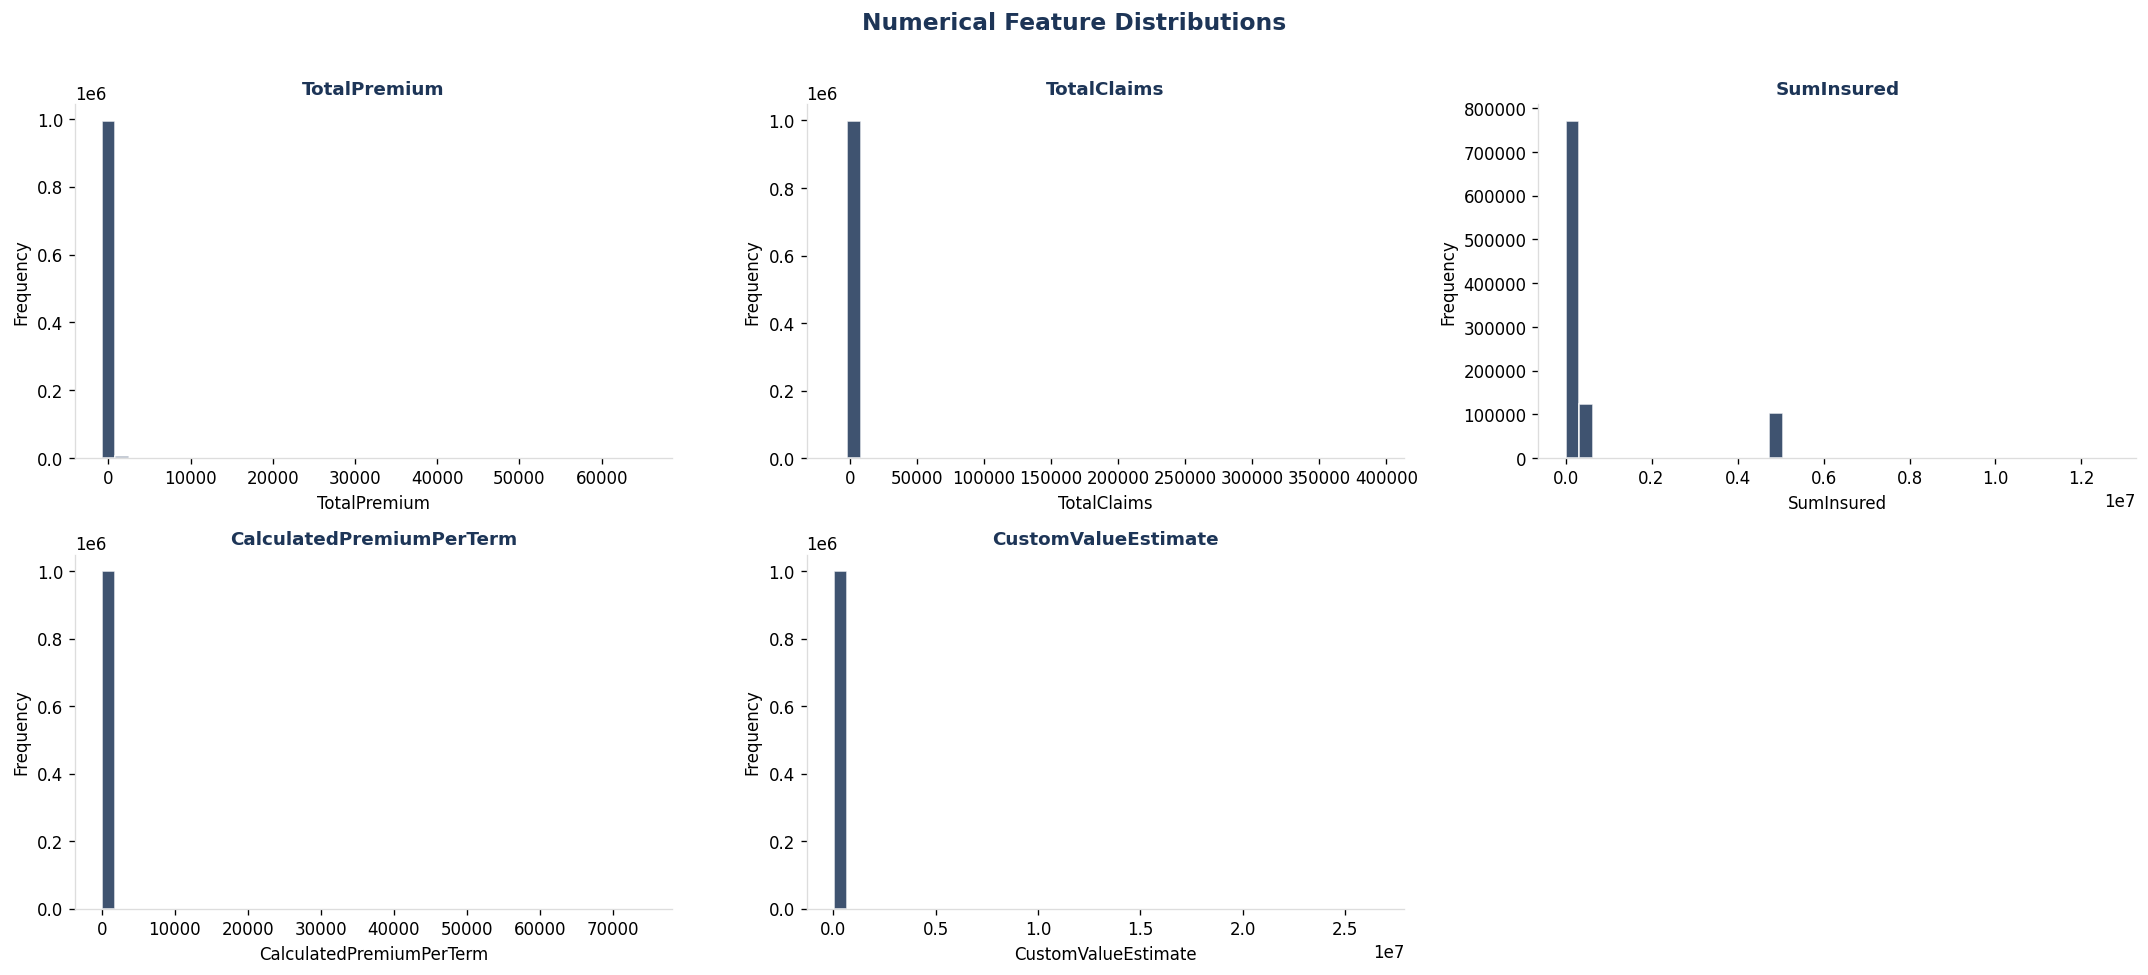

In [46]:
numerical_cols = ["TotalPremium", "TotalClaims", "SumInsured",
                  "CalculatedPremiumPerTerm", "CustomValueEstimate"]
numerical_cols = [c for c in numerical_cols if c in df.columns]

plot_numerical_distributions(df, numerical_cols)

### Insight

The numerical distributions reveal that most financial variables are highly right-skewed, indicating that a small number of policies account for disproportionately large values. This is common in insurance datasets where a minority of high-risk customers generate significantly larger premiums or claims compared to the majority.

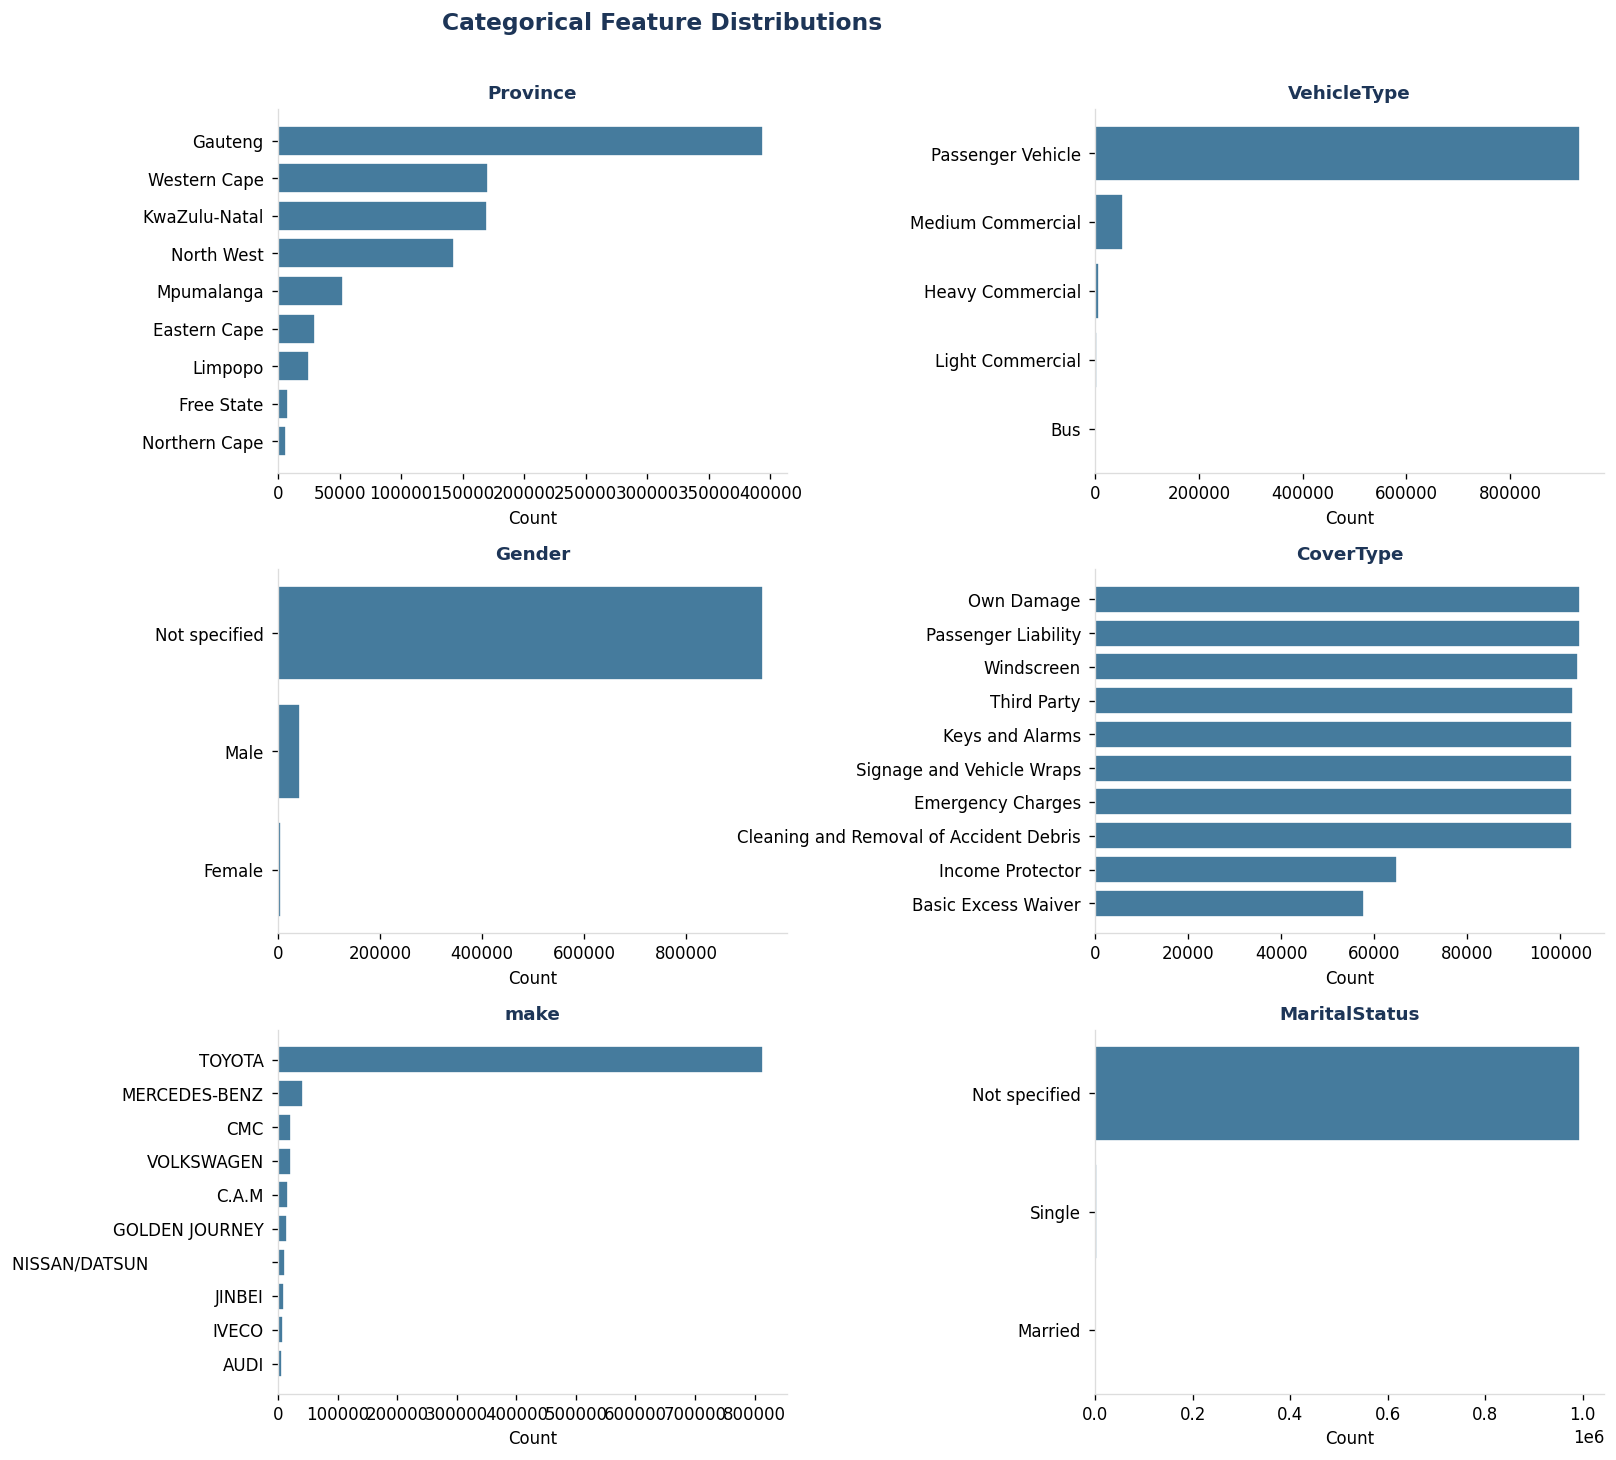

In [47]:
categorical_cols = ["Province", "VehicleType", "Gender",
                    "CoverType", "make", "MaritalStatus"]
categorical_cols = [c for c in categorical_cols if c in df.columns]

plot_categorical_distributions(df, categorical_cols)

### Insight

The categorical analysis highlights the composition of the insurance portfolio across customer demographics, vehicle characteristics, and geographic regions. Certain categories dominate the dataset, suggesting concentration in specific customer segments and potential imbalance across regions or vehicle types.

## 7. Bivariate & Multivariate Analysis

Relationships between TotalPremium and TotalClaims broken down by Province
and PostalCode, alongside a correlation matrix of key financial variables.

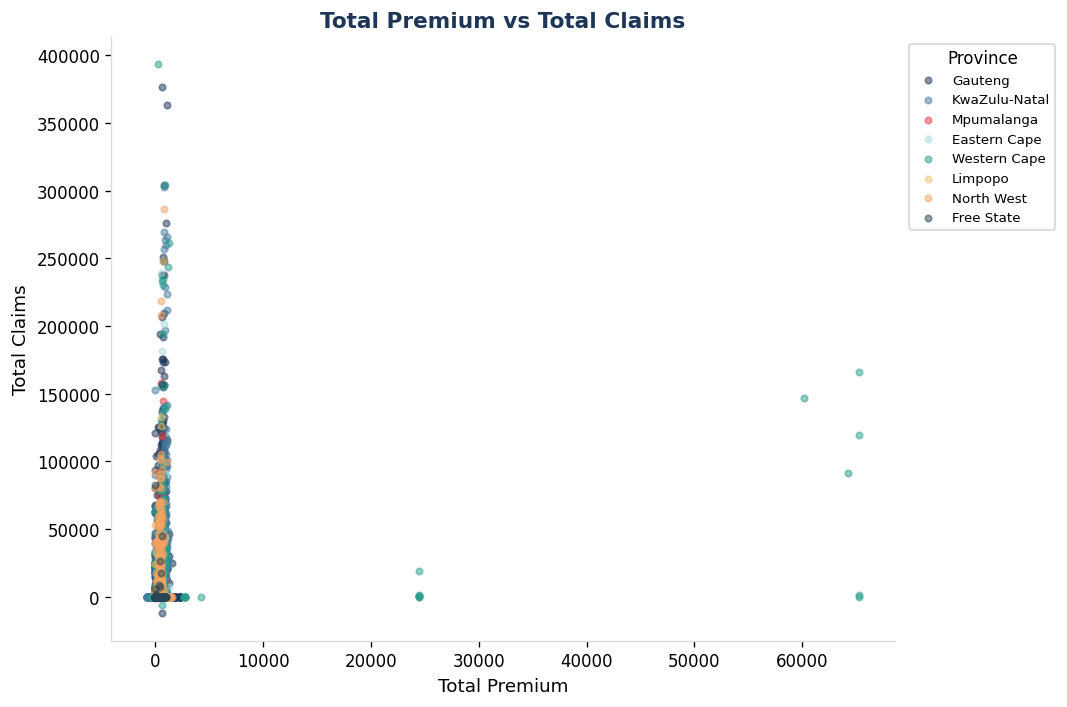

In [48]:
plot_premium_vs_claims(df, hue_col="Province")

### Insight

The scatterplot comparing TotalPremium and TotalClaims demonstrates the relationship between customer premiums and claim amounts. While higher premiums are generally associated with higher claims exposure, the presence of extreme outliers indicates that some customers incur unusually large claims relative to their premium contributions.

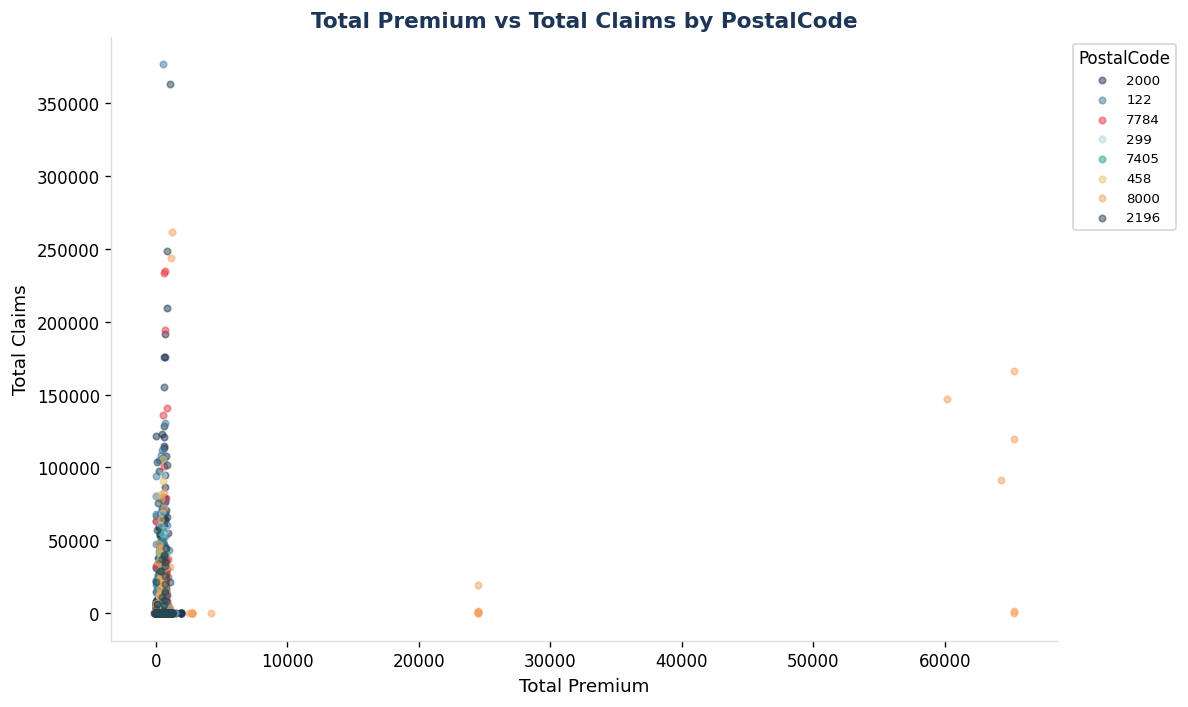

In [49]:
plot_premium_vs_claims_by_postalcode(df)

### Insight

The postal code analysis reveals geographic variation in insurance performance. Certain locations exhibit significantly higher claims relative to premiums, suggesting regional differences in risk exposure, accident frequency, or customer behavior patterns.

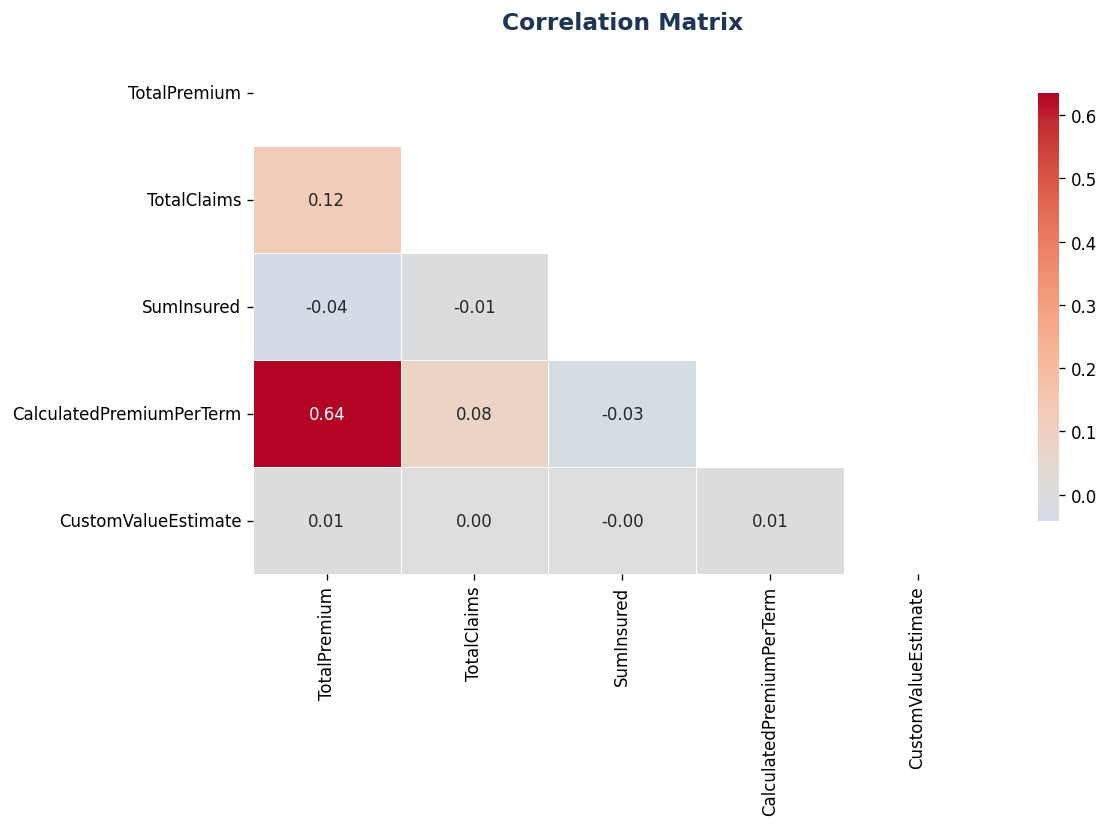

In [50]:
corr_cols = ["TotalPremium", "TotalClaims", "SumInsured",
             "CalculatedPremiumPerTerm", "CustomValueEstimate"]
corr_cols = [c for c in corr_cols if c in df.columns]

plot_correlation_matrix(df, corr_cols)

### Insight

The correlation matrix shows the relationships between numerical variables such as TotalPremium, TotalClaims, and SumInsured. Moderate positive relationships suggest that customers with larger insured amounts tend to pay higher premiums, while claims exhibit weaker correlations, indicating that claim occurrence may depend on additional external risk factors.

## 8. Geographic Trends

Comparing average premium and claims, and claim rates, across provinces
to identify high-risk and low-risk regions.

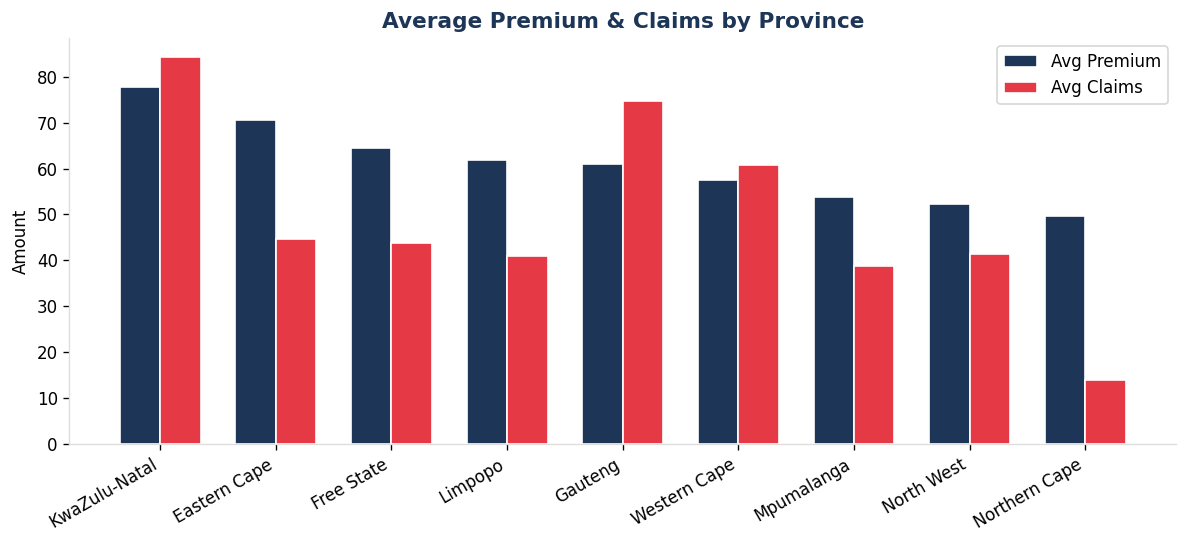

In [51]:
plot_province_analysis(df)

### Insight

The province-based analysis highlights regional disparities in premiums and claims. Some provinces generate consistently higher claims activity, which may reflect population density, traffic conditions, economic factors, or varying insurance behaviors across regions.

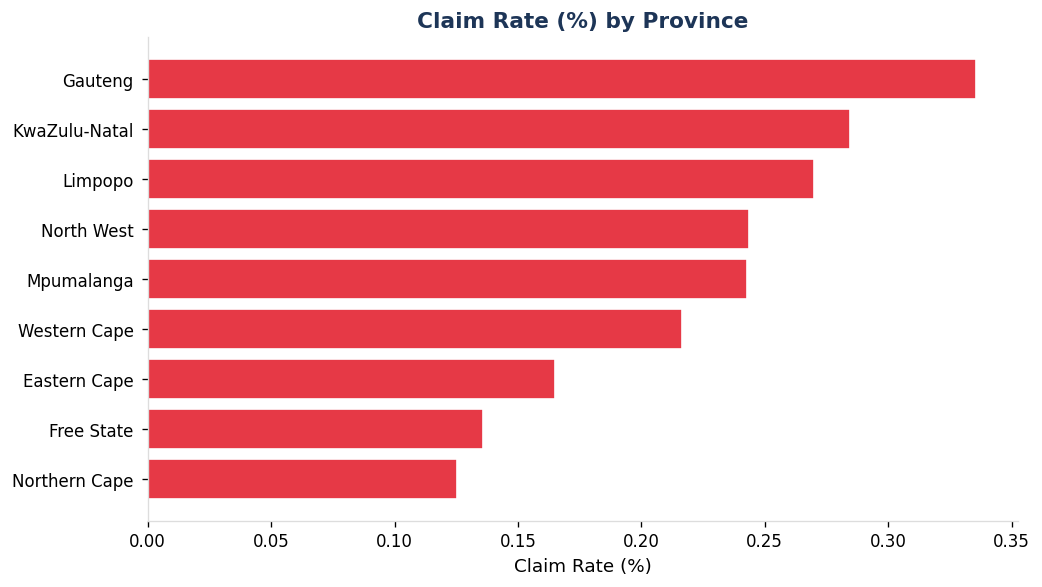

In [52]:
plot_claim_rate_by_group(df, "Province")

### Insight

The claim rate comparison across provinces helps identify regions associated with elevated insurance risk. Differences across provinces may support future segmentation strategies and more targeted pricing or underwriting decisions.

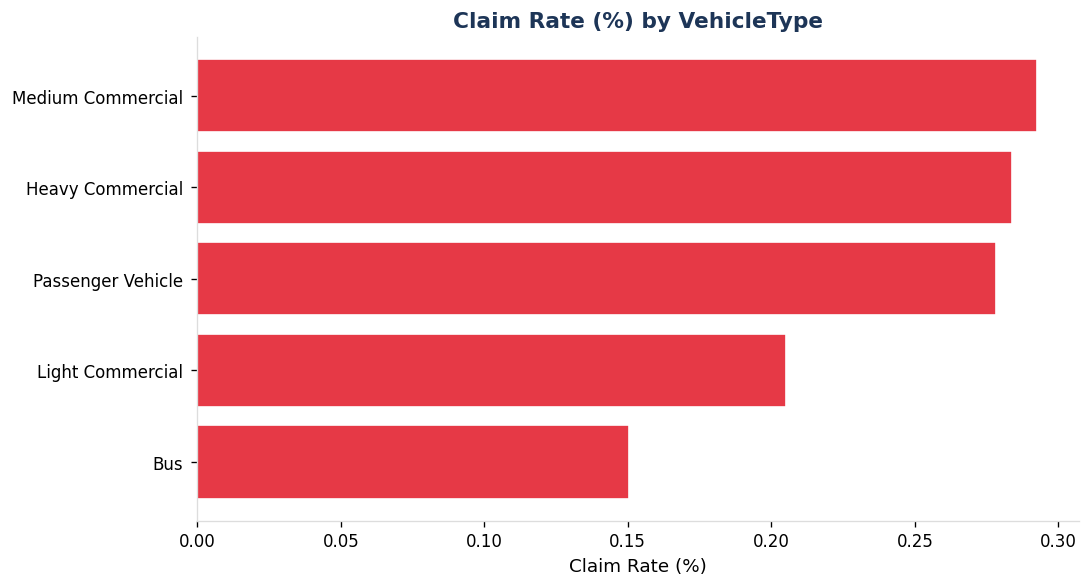

In [53]:
if "VehicleType" in df.columns:
    plot_claim_rate_by_group(df, "VehicleType")

### Insight

The vehicle type analysis suggests that certain vehicle categories are associated with higher claim frequencies or severities. These differences may reflect repair costs, accident exposure, or driver usage patterns across vehicle classes.

## 9. Outlier Detection

Box plots on key numerical features to identify extreme values
that could skew analysis.

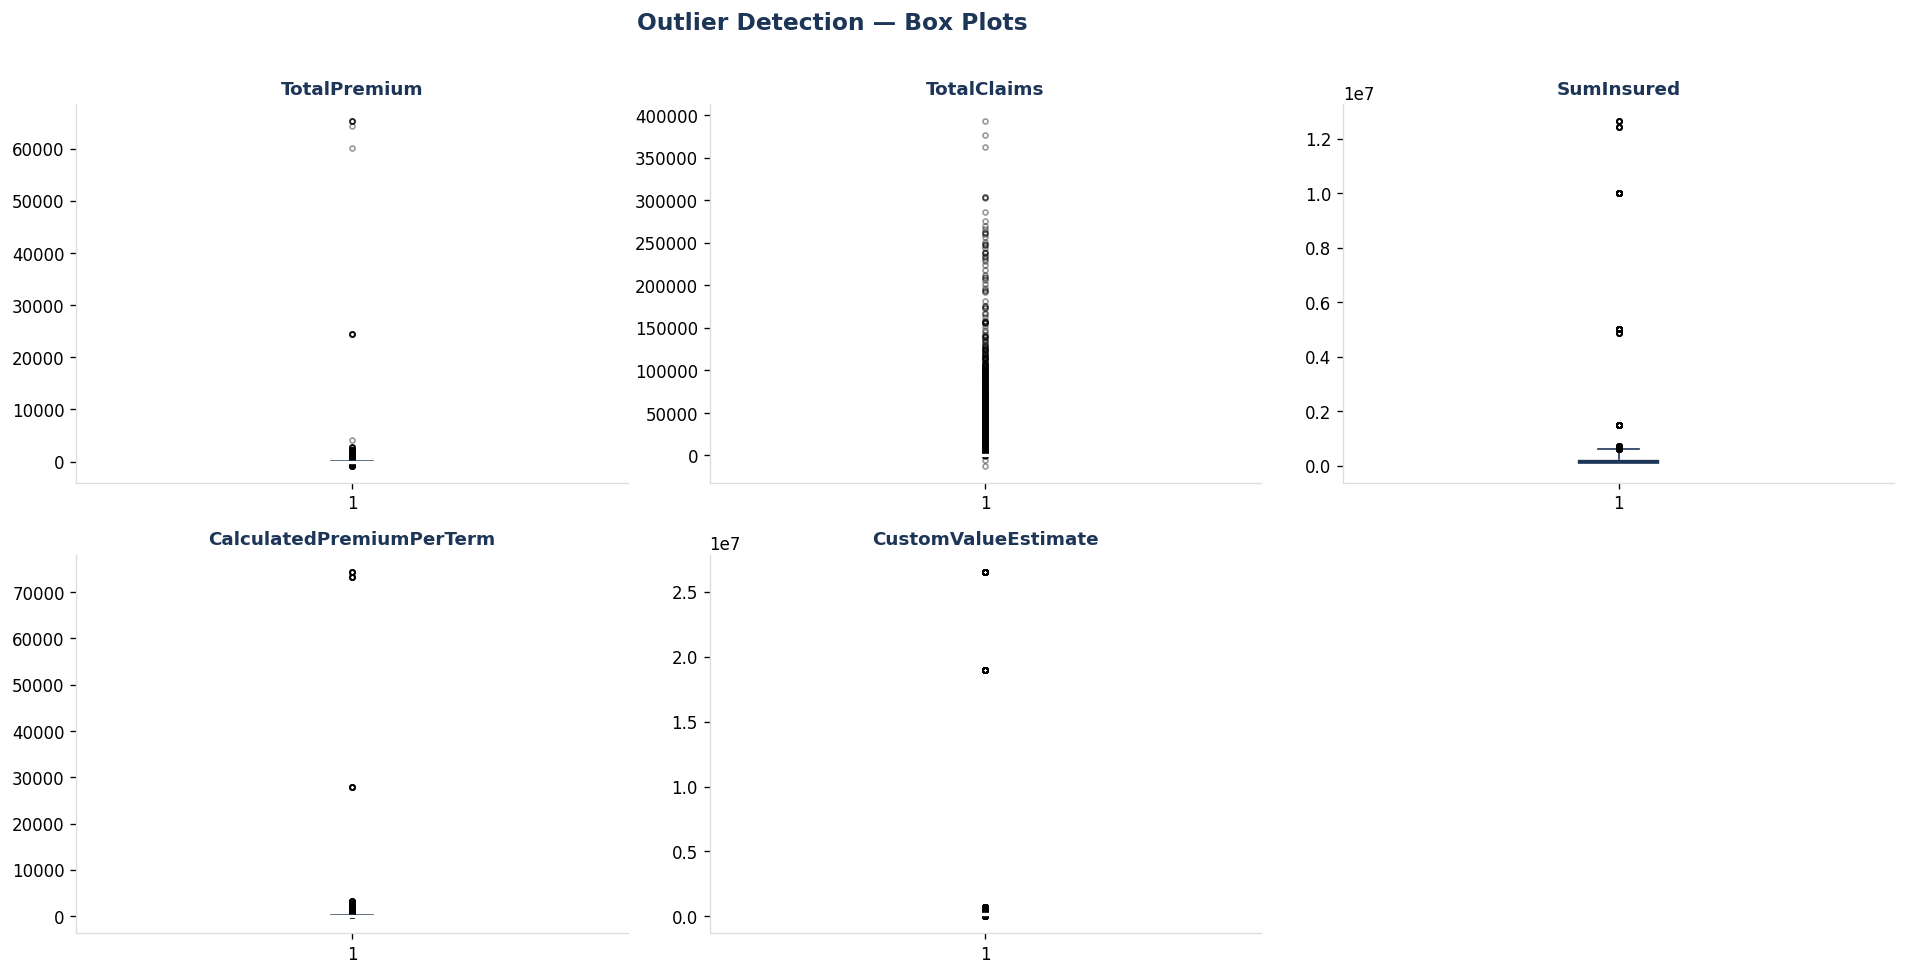

In [54]:
plot_boxplots(df, numerical_cols)

### Insight

The boxplots reveal substantial outliers in variables such as TotalClaims and CustomValueEstimate. These extreme observations indicate the presence of high-cost claims and unusually valuable insured vehicles, both of which can heavily influence insurance risk and portfolio profitability.

## 10. Loss Ratio Analysis

**Loss Ratio = TotalClaims / TotalPremium**

- Loss ratio **above 1.0** → insurer pays out more than it collects (unprofitable)
- Loss ratio **below 1.0** → portfolio is profitable

In [55]:
overall_loss_ratio = compute_loss_ratio(df)
print(f"Overall Loss Ratio: {overall_loss_ratio:.4f}")

print("\nLoss Ratio by Province:")
print(compute_loss_ratio(df, "Province"))

if "VehicleType" in df.columns:
    print("\nLoss Ratio by VehicleType:")
    print(compute_loss_ratio(df, "VehicleType"))

if "Gender" in df.columns:
    print("\nLoss Ratio by Gender:")
    print(compute_loss_ratio(df, "Gender"))

Overall Loss Ratio: 1.0477

Loss Ratio by Province:
Province
Gauteng          1.222018
KwaZulu-Natal    1.082693
Western Cape     1.059472
North West       0.790367
Mpumalanga       0.720897
Free State       0.680758
Limpopo          0.661199
Eastern Cape     0.633813
Northern Cape    0.282699
Name: LossRatio, dtype: float64

Loss Ratio by VehicleType:
VehicleType
Heavy Commercial     1.628112
Medium Commercial    1.050251
Passenger Vehicle    1.047538
Light Commercial     0.232066
Bus                  0.137292
Name: LossRatio, dtype: float64

Loss Ratio by Gender:
Gender
Not specified    1.053204
Male             0.883910
Female           0.821879
Name: LossRatio, dtype: float64


### Insight

The loss ratio analysis evaluates the balance between collected premiums and incurred claims. Higher loss ratios indicate customer groups or regions where claims costs consume a larger proportion of premiums, potentially signaling unprofitable segments that may require pricing adjustments.

## 11. Temporal Trends

How premiums and claims evolved over the 18-month period (Feb 2014 – Aug 2015).

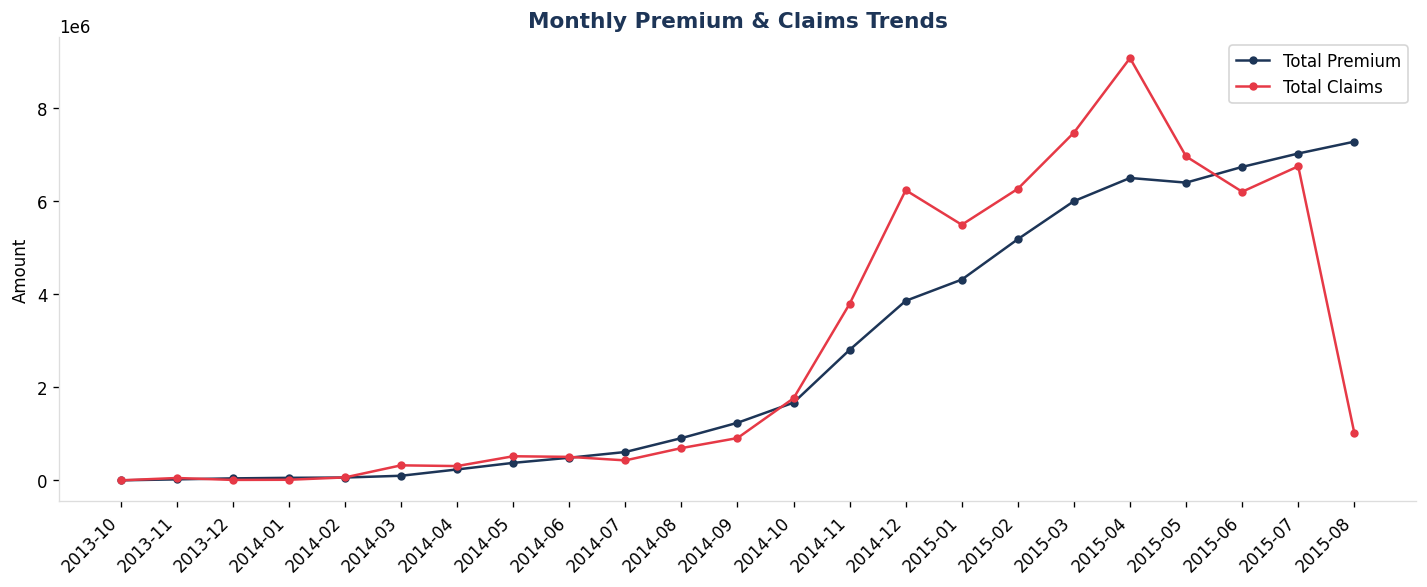

In [56]:
if "TransactionMonth" in df.columns:
    df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])
    monthly = df.groupby(df["TransactionMonth"].dt.to_period("M"))[
        ["TotalPremium", "TotalClaims"]
    ].sum()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly.index.astype(str), monthly["TotalPremium"],
            label="Total Premium", color=PALETTE["primary"], marker="o", markersize=4)
    ax.plot(monthly.index.astype(str), monthly["TotalClaims"],
            label="Total Claims", color=PALETTE["accent"], marker="o", markersize=4)
    ax.set_xticklabels(monthly.index.astype(str), rotation=45, ha="right")
    ax.set_title("Monthly Premium & Claims Trends", fontsize=13,
                 fontweight="bold", color=PALETTE["primary"])
    ax.set_ylabel("Amount")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Insight

The monthly trend analysis illustrates how premiums and claims evolve over time. Fluctuations in claims activity compared to premium collection may indicate seasonal risk patterns, operational changes, or shifts in customer behavior throughout the observed period.

## 12. Vehicle Makes by Claim Amount

Identifying which vehicle makes carry the highest and lowest average claim amounts.

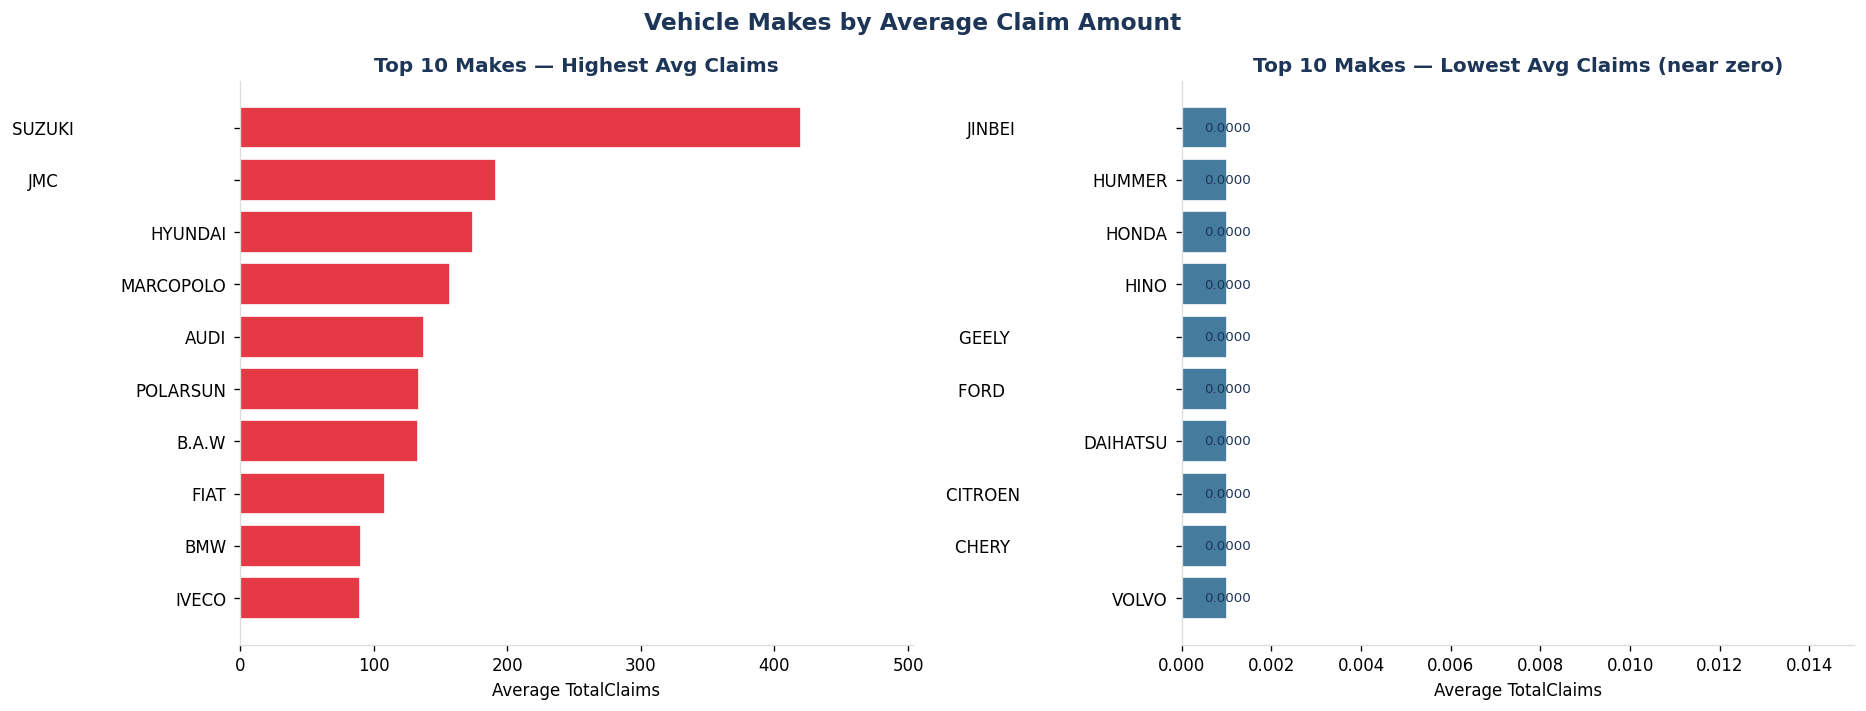

In [57]:
plot_vehicle_makes_by_claims(df, top_n=10)

### Insight

The analysis of vehicle makes against claim amounts suggests that certain vehicle brands are associated with higher claim frequencies or severities. This may reflect differences in repair costs, theft rates, vehicle performance, or driver demographics.


- Insurance claims and premiums are heavily right-skewed, with a small subset of customers contributing disproportionately large financial values.
- Geographic location appears to influence insurance performance, with certain provinces and postal codes showing elevated claims activity.
- Significant outliers exist in both claims and vehicle value estimates, indicating the presence of high-risk and high-value policyholders.
- Vehicle characteristics and customer segmentation variables may provide meaningful signals for future risk modeling and pricing optimization.
- Temporal trends suggest that claims behavior changes over time and may exhibit seasonal dynamics.
- Loss ratio analysis indicates that some customer segments may be less profitable and could require pricing or underwriting adjustments.

## 13. Key Insights & Summary

| Question | Finding |
|---|---|
| **Overall Loss Ratio** | 1.0477 — the portfolio is currently **unprofitable**, paying out more in claims than it collects in premiums |
| **Highest risk provinces** | Gauteng (1.22), KwaZulu-Natal (1.08), Western Cape (1.06) — all above 1.0, losses exceed premiums |
| **Lowest risk provinces** | Northern Cape (0.28), Eastern Cape (0.63), Limpopo (0.66) — well below 1.0, profitable segments |
| **Vehicle types with highest loss ratio** | Heavy Commercial (1.63) and Medium Commercial (1.05) are unprofitable; Light Commercial (0.23) and Bus (0.14) are the most profitable |
| **Gender with higher loss ratio** | "Not specified" (1.05) and Male (0.88) carry higher risk than Female (0.82) |
| **Temporal trends** | Both premiums and claims were minimal until late 2014, then grew sharply. Claims exceeded premiums consistently from Oct 2014 onwards. April 2015 was the worst month with claims ~40% above premiums (~9M vs ~6.5M). The Aug 2015 claims drop is likely due to incomplete data for that final month |
| **Vehicle makes with highest claims** | Suzuki (~420), JMC (~190), Hyundai (~165), Marcopolo (~155), Audi (~135) |
| **Vehicle makes with lowest claims** | Jinbei, Hummer, Honda, Hino, Geely, Ford, Daihatsu, Citroen, Chery, Volvo — all with near-zero average claims |

---

## Strategic Recommendations

- **Gauteng, KwaZulu-Natal, Western Cape** require immediate premium repricing —
  loss ratios above 1.0 indicate systematic underpricing in these provinces
- **Heavy Commercial vehicles** are the highest-risk segment (loss ratio 1.63) —
  premiums should be reviewed and risk controls strengthened
- **Suzuki and JMC** carry disproportionately high average claim amounts —
  underwriting guidelines for these makes should be reviewed
- **Northern Cape and Light Commercial** are the most profitable segments —
  ideal targets for customer acquisition and retention campaigns
- **Female policyholders** show the lowest loss ratio (0.82) —
  a strong segment for targeted loyalty and discount programs
- **Portfolio growth was rapid from late 2014** but claims grew faster than premiums —
  suggesting the growth was not adequately priced for risk